In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 1. Loading data and injecting noise

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


file_path = '/kaggle/input/datasets/dskagglemt/student-performance-data-set/student-mat.csv'


df = pd.read_csv(file_path, sep=None, engine='python')


np.random.seed(42)
df = pd.concat([df, df.sample(10)], ignore_index=True) # Duplicates
df.loc[np.random.choice(df.index, 15), 'age'] = np.nan # Missing ages
df.loc[np.random.choice(df.index, 20), 'absences'] = np.nan # Missing absences



print("Initial Dataset Shape (with injected noise):", df.shape)
print("Columns successfully loaded:", df.columns[:5].tolist(), "... and G3 is at the end!")


Initial Dataset Shape (with injected noise): (405, 33)
Columns successfully loaded: ['school', 'sex', 'age', 'address', 'famsize'] ... and G3 is at the end!


# 2. Removing duplicates

In [2]:
print("--- Removing Duplicates ---")
print(f"Before: {df.shape[0]} rows")
df = df.drop_duplicates()
print(f"After: {df.shape[0]} rows")

--- Removing Duplicates ---
Before: 405 rows
After: 397 rows


# 3. Handling missing values

In [3]:
print("--- Handling Missing Values ---")
print("Before:\n", df.isnull().sum()[df.isnull().sum() > 0])


numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns


for col in numeric_cols:
    if df[col].isnull().sum() > 0:  
        df[col] = df[col].fillna(df[col].median())


for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nAfter:\n", df.isnull().sum()[df.isnull().sum() > 0]) 
print("(If the 'After' list is empty, all missing values are handled!)")

--- Handling Missing Values ---
Before:
 age         15
absences    20
dtype: int64

After:
 Series([], dtype: int64)
(If the 'After' list is empty, all missing values are handled!)


# 4. Dropping Outliers

--- Outlier Detection (All Numeric Columns) ---
Before Outliers Removal: 397 rows
After Outliers Removal: 222 rows


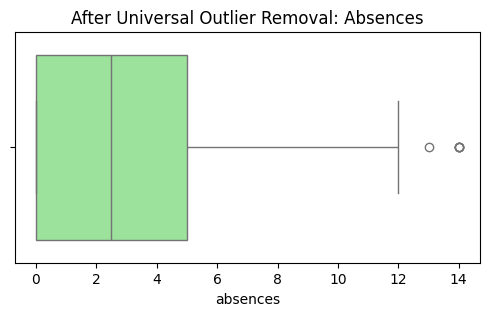

In [4]:
print("--- Outlier Detection (All Numeric Columns) ---")
print(f"Before Outliers Removal: {df.shape[0]} rows")


numeric_cols = df.select_dtypes(include=['number']).columns


for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"After Outliers Removal: {df.shape[0]} rows")


plt.figure(figsize=(6,3))
sns.boxplot(x=df['absences'], color='lightgreen')
plt.title("After Universal Outlier Removal: Absences")
plt.show()

# 5. Variable Encoding

In [5]:
print("--- Encoding Variables ---")
print("Before Encoding (Categorical columns sample):\n", df.select_dtypes(include=['object']).head(2))


X = df.drop(['G3'], axis=1) # G3 is the final grade 
y = df['G3']


categorical_cols = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nAfter Encoding (Features Shape):", X_encoded.shape)
print("After Encoding (Sample):\n", X_encoded.head(2).iloc[:, :5])

--- Encoding Variables ---
Before Encoding (Categorical columns sample):
   school sex address famsize Pstatus     Mjob     Fjob  reason guardian  \
0     GP   F       U     GT3       A  at_home  teacher  course   mother   
1     GP   F       U     GT3       T  at_home    other  course   father   

  schoolsup famsup paid activities nursery higher internet romantic  
0       yes     no   no         no     yes    yes       no       no  
1        no    yes   no         no      no    yes      yes       no  

After Encoding (Features Shape): (222, 41)
After Encoding (Sample):
     age  Medu  Fedu  traveltime  studytime
0  18.0     4     4           2          2
1  17.0     1     1           1          2


# 6. Feature Selection

In [6]:
print("--- Feature Selection ---")
print(f"Before Selection: {X_encoded.shape[1]} features")


temp_df = X_encoded.copy()
temp_df['G3'] = y


corressions = temp_df.corr()['G3'].drop('G3').abs()


selected_features = corressions[corressions > 0.05].index
X_selected = X_encoded[selected_features]

print(f"After Selection: {X_selected.shape[1]} features kept based on correlation.")

--- Feature Selection ---
Before Selection: 41 features
After Selection: 28 features kept based on correlation.


# 7. Feature Scaling

In [7]:
print("--- Feature Scaling ---")
print("Before Scaling (Sample Data):\n", X_selected.iloc[:2, :3])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_selected), columns=X_selected.columns)

print("\nAfter Scaling (Sample Data):\n", X_scaled.iloc[:2, :3])

--- Feature Scaling ---
Before Scaling (Sample Data):
     age  Medu  Fedu
0  18.0     4     4
1  17.0     1     1

After Scaling (Sample Data):
        age      Medu      Fedu
0  1.39915  1.014928  1.227387
1  0.49093 -1.710646 -1.671335


# 8. Checking Imbalance

--- Target Distribution (Checking 'Imbalance' for Regression) ---


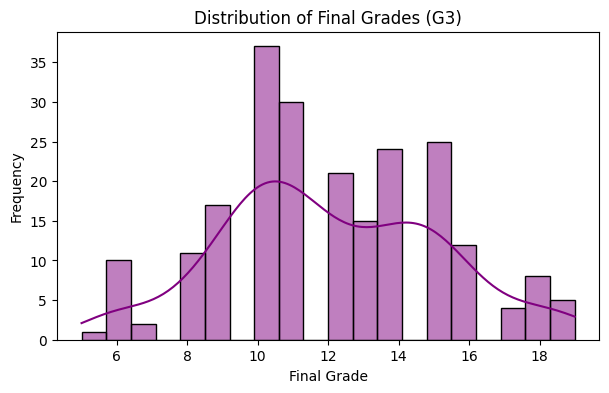

In [8]:
print("--- Target Distribution (Checking 'Imbalance' for Regression) ---")
plt.figure(figsize=(7, 4))
sns.histplot(y, bins=20, kde=True, color='purple')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Frequency')
plt.show()


# 9. Data Splitting

In [9]:
print("--- Train/Test Split ---")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape[0]} samples")
print(f"Testing Data: {X_test.shape[0]} samples")

--- Train/Test Split ---
Training Data: 177 samples
Testing Data: 45 samples


# 10. Model Training

In [10]:
print("--- Training Model & Predicting New Values ---")

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


new_student_data = X_test.iloc[[0]] 
new_prediction = model.predict(new_student_data)

print(f"Predicted Final Grade (G3) for the new student: {new_prediction[0]:.2f}")
print(f"Actual Grade was: {y_test.iloc[0]}")

--- Training Model & Predicting New Values ---
Predicted Final Grade (G3) for the new student: 11.06
Actual Grade was: 11


# 11. External Test Data 

In [12]:
import pandas as pd
import numpy as np

print("======================================================")
print("              REAL-WORLD PREDICTION ENGINE          ")
print("======================================================\n")



# --- PROFILE 1: The High Achiever ---
new_student_profile = {
    'school': 'GP', 'sex': 'F', 'age': 16, 'address': 'U', 'famsize': 'LE3',
    'Pstatus': 'T', 'Medu': 4, 'Fedu': 4, 'Mjob': 'teacher', 'Fjob': 'health',
    'reason': 'reputation', 'guardian': 'mother', 'traveltime': 1, 'studytime': 4,
    'failures': 0, 'schoolsup': 'yes', 'famsup': 'yes', 'paid': 'yes',
    'activities': 'yes', 'nursery': 'yes', 'higher': 'yes', 'internet': 'yes',
    'romantic': 'no', 'famrel': 5, 'freetime': 2, 'goout': 2, 'Dalc': 1,
    'Walc': 1, 'health': 5, 'absences': 0, 
    'G1': 18, 'G2': 19   
}

# --- PROFILE 2: The Struggling Student ---
# new_student_profile = {
#     'school': 'MS', 'sex': 'M', 'age': 18, 'address': 'R', 'famsize': 'GT3',
#     'Pstatus': 'A', 'Medu': 1, 'Fedu': 1, 'Mjob': 'at_home', 'Fjob': 'other',
#     'reason': 'course', 'guardian': 'other', 'traveltime': 3, 'studytime': 1,
#     'failures': 2, 'schoolsup': 'no', 'famsup': 'no', 'paid': 'no',
#     'activities': 'no', 'nursery': 'no', 'higher': 'no', 'internet': 'no',
#     'romantic': 'yes', 'famrel': 2, 'freetime': 4, 'goout': 5, 'Dalc': 3,
#     'Walc': 4, 'health': 2, 'absences': 22, 
#     'G1': 6, 'G2': 7   
# }

# --- PROFILE 3: The Late Bloomer ---
# new_student_profile = {
#     'school': 'GP', 'sex': 'M', 'age': 17, 'address': 'U', 'famsize': 'GT3',
#     'Pstatus': 'T', 'Medu': 2, 'Fedu': 3, 'Mjob': 'services', 'Fjob': 'services',
#     'reason': 'home', 'guardian': 'father', 'traveltime': 2, 'studytime': 3,
#     'failures': 0, 'schoolsup': 'yes', 'famsup': 'yes', 'paid': 'yes',
#     'activities': 'yes', 'nursery': 'yes', 'higher': 'yes', 'internet': 'yes',
#     'romantic': 'no', 'famrel': 4, 'freetime': 3, 'goout': 3, 'Dalc': 1,
#     'Walc': 2, 'health': 4, 'absences': 4, 
#     'G1': 9, 'G2': 13   
# }


test_df = pd.DataFrame([new_student_profile])


test_encoded = pd.get_dummies(test_df)
test_aligned = test_encoded.reindex(columns=X_selected.columns, fill_value=0)


test_scaled_array = scaler.transform(test_aligned)


test_scaled_df = pd.DataFrame(test_scaled_array, columns=X_selected.columns)


predicted_grade = model.predict(test_scaled_df)[0]


print("[1] KEY STUDENT FEATURES (Input Data):")
print(test_df[['sex', 'studytime', 'absences', 'G1', 'G2']].to_string(index=False)) 

print("\n[2] PREDICTION RESULT:")
print("------------------------------------------------------")
print(f" Model's Predicted Final Grade (G3):  {predicted_grade:.2f} / 20")
print("------------------------------------------------------")
print("Note: This is a forward-looking prediction for a new student.")
print("======================================================")

              REAL-WORLD PREDICTION ENGINE          

[1] KEY STUDENT FEATURES (Input Data):
sex  studytime  absences  G1  G2
  F          4         0  18  19

[2] PREDICTION RESULT:
------------------------------------------------------
 Model's Predicted Final Grade (G3):  18.61 / 20
------------------------------------------------------
Note: This is a forward-looking prediction for a new student.


# 12. Test Accuracy

In [13]:
print("--- Evaluation Metrics ---")
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R²): {r2:.2f}")

--- Evaluation Metrics ---
Mean Squared Error (MSE): 0.58
Root Mean Squared Error (RMSE): 0.76
R-squared Score (R²): 0.93


# 13. Visualization

--- Visualizing Actual vs. Predicted Results ---


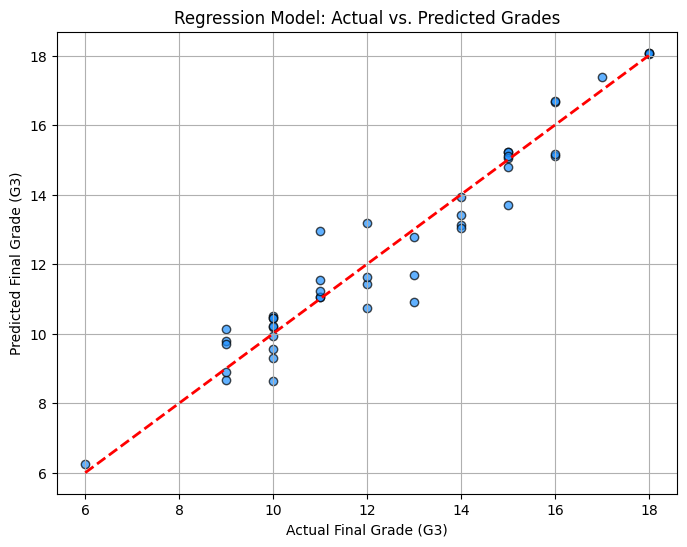

In [14]:
print("--- Visualizing Actual vs. Predicted Results ---")
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='dodgerblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Final Grade (G3)')
plt.ylabel('Predicted Final Grade (G3)')
plt.title('Regression Model: Actual vs. Predicted Grades')
plt.grid(True)
plt.show()

--- Actual vs. Predicted Data ---

[Data Table: 15 Random Students]
    Actual Grade  Predicted Grade
0             12            10.75
1             10            10.46
2             14            13.42
3             18            18.06
4             15            14.80
5             16            16.68
6             10            10.18
7             13            11.68
8              6             6.25
9             11            11.05
10            14            13.94
11            13            10.92
12            15            15.10
13             9            10.14
14            16            15.11


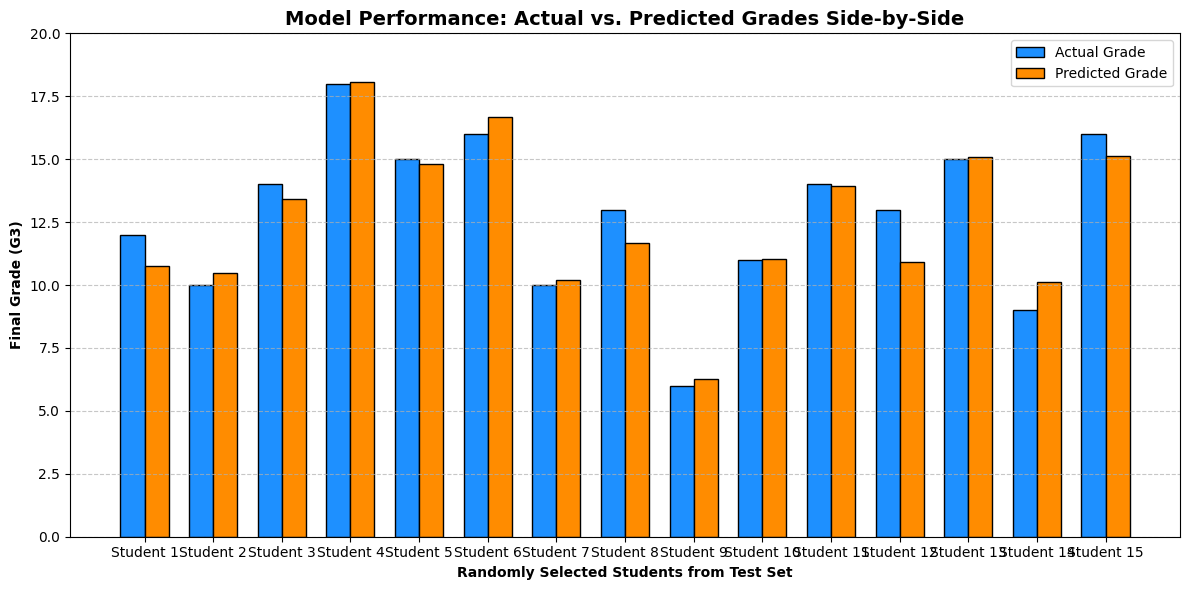

In [15]:
import numpy as np

print("--- Actual vs. Predicted Data ---")


results_df = pd.DataFrame({
    'Actual Grade': y_test, 
    'Predicted Grade': np.round(y_pred, 2)
})


sample_df = results_df.sample(15, random_state=42).reset_index(drop=True)


print("\n[Data Table: 15 Random Students]")
print(sample_df.to_string())


plt.figure(figsize=(12, 6))

x = np.arange(len(sample_df))  
width = 0.35  
plt.bar(x - width/2, sample_df['Actual Grade'], width, label='Actual Grade', color='dodgerblue', edgecolor='black')
plt.bar(x + width/2, sample_df['Predicted Grade'], width, label='Predicted Grade', color='darkorange', edgecolor='black')


plt.xlabel('Randomly Selected Students from Test Set', fontweight='bold')
plt.ylabel('Final Grade (G3)', fontweight='bold')
plt.title('Model Performance: Actual vs. Predicted Grades Side-by-Side', fontsize=14, fontweight='bold')
plt.xticks(x, [f"Student {i+1}" for i in range(len(sample_df))])
plt.ylim(0, 20) 
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np
from IPython.display import display


comparison_table = pd.DataFrame({
    'Actual Grade': y_test.values, 
    'Predicted Grade': np.round(y_pred, 2)
})


colored_table = (
    comparison_table.style
    .set_properties(subset=['Actual Grade'], 
                    **{'background-color': '#d1e7dd', 'color': 'black', 'text-align': 'center', 'font-weight': 'bold'})
    .set_properties(subset=['Predicted Grade'], 
                    **{'background-color': '#fff3cd', 'color': 'black', 'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('font-size', '14px'), ('background-color', '#f8f9fa')]}
    ])
    .hide(axis="index")
)

print("====================================")
print("     ACTUAL VS PREDICTED GRADES     ")
print("====================================\n")


display(colored_table)

     ACTUAL VS PREDICTED GRADES     



Actual Grade,Predicted Grade
11,11.060000
10,9.550000
10,10.510000
11,11.050000
10,10.180000
10,10.450000
14,13.940000
16,16.660000
6,6.250000
18,18.080000
